<a href="https://colab.research.google.com/github/gravityeffect1/CysteineBRCA1/blob/main/CBRCA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRCA1 Protein Cysteine Residue Analysis

This Google Colab notebook provides a pipeline to fetch protein data from the UniProt API, extract its sequence, identify Cysteine (C) residue positions, and visualize these positions.

## Table of Contents
1.  [Introduction](#introduction)
2.  [Pipeline Steps](#pipeline-steps)
3.  [Default Protein](#default-protein)
4.  [Usage](#usage)
5.  [Functions](#functions)

## Introduction
Cysteine residues play crucial roles in protein structure and function, often forming disulfide bonds that stabilize protein folds or participating in catalytic activities. This notebook offers a programmatic way to analyze the distribution of Cysteine residues within a given protein sequence using public bioinformatics data.

## Pipeline Steps
1.  **Fetch Protein Data**: Retrieves comprehensive protein information, including the amino acid sequence, from the UniProt API using a specified accession ID.
2.  **Extract Protein Sequence**: Parses the fetched data to isolate the raw amino acid sequence.
3.  **Find Cysteine Positions**: Identifies all occurrences of Cysteine residues ('C') within the extracted sequence and records their 0-based indices.
4.  **Plot Cysteine Positions**: Generates a scatter plot visualizing the 1-based positions of Cysteine residues along the protein sequence, providing a quick overview of their distribution.

## Default Protein
By default, this notebook is configured to analyze the **BRCA1 protein** (UniProt Accession ID: `P38398`).

## Usage
To use this notebook, simply run all cells. You can modify the `brca1_accession_id` and `protein_name` variables in the last code cell to analyze a different protein.

## Functions
-   `fetch_protein_data(accession_id)`: Fetches protein data from UniProt.
-   `extract_protein_sequence(protein_data)`: Extracts the sequence from the fetched data.
-   `find_cysteine_positions(sequence)`: Locates Cysteine residues in a sequence.
-   `plot_cysteine_positions(sequence_length, cysteine_positions, protein_name)`: Plots the positions of Cysteine residues.

In [3]:
import urllib.request
import json

def fetch_protein_data(accession_id):
    """
    Fetches protein data from the UniProt API for a given accession ID.

    Args:
        accession_id (str): The UniProt accession ID of the protein.

    Returns:
        dict: The JSON data of the protein, or None if an error occurs.
    """
    coordinates_url = f"https://www.ebi.ac.uk/proteins/api/coordinates/{accession_id}?format=json"
    try:
        with urllib.request.urlopen(coordinates_url) as r:
            data = json.loads(r.read())
        return data
    except urllib.error.URLError as e:
        print(f"Error fetching data for {accession_id}: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON for {accession_id}: {e}")
        return None

In [4]:
def extract_protein_sequence(protein_data):
    """
    Extracts the protein sequence from the fetched protein data.

    Args:
        protein_data (dict): The dictionary containing protein information.

    Returns:
        str: The protein sequence, or None if not found.
    """
    if protein_data and 'sequence' in protein_data:
        return protein_data['sequence']
    else:
        print("Warning: Protein sequence not found in the provided data.")
        return None

In [11]:
import matplotlib.pyplot as plt

def plot_cysteine_positions(sequence_length, cysteine_positions, protein_name="Protein"):
    """
    Plots the positions of Cysteine residues in a protein sequence.

    Args:
        sequence_length (int): The total length of the protein sequence.
        cysteine_positions (list): A list of 0-based indices of Cysteine residues.
        protein_name (str): The name of the protein for the plot title.
    """
    if not cysteine_positions:
        print(f"No Cysteine residues to plot for {protein_name}.")
        return


    plot_positions = [p + 1 for p in cysteine_positions]

    y_values = [1] * len(plot_positions)

    fig, ax = plt.subplots(figsize=(15, 3))
    ax.scatter(plot_positions, y_values, marker='|', s=200, color='blue')

    ax.set_title(f'Positions of Cysteine Residues in {protein_name} Sequence')
    ax.set_xlabel('Amino Acid Position (1-based)')
    ax.set_ylabel('Cysteine Presence')
    ax.set_yticks([])
    ax.set_xlim(0, sequence_length + 1)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Protein Cysteine Residue Analysis Pipeline

This section demonstrates a pipeline for analyzing protein data from UniProt, specifically to identify and visualize the positions of Cysteine residues.

The pipeline consists of the following steps:
1.  **Fetch Protein Data**: Retrieve comprehensive protein information from the UniProt API using an accession ID.
2.  **Extract Protein Sequence**: Isolate the amino acid sequence from the fetched data.
3.  **Find Cysteine Positions**: Identify all occurrences of Cysteine (C) residues within the sequence and record their positions.
4.  **Plot Cysteine Positions**: Visualize these positions along the protein sequence.

In [15]:
def find_cysteine_positions(sequence):
    """
    Finds the 0-based indices of all Cysteine (C) residues in a protein sequence.

    Args:
        sequence (str): The protein sequence.

    Returns:
        list: A list of 0-based indices where Cysteine residues are found.
    """
    if not sequence:
        return []
    return [i for i, char in enumerate(sequence) if char == 'C']

Fetching data for BRCA1 (Accession ID: P38398)...
Extracting sequence for BRCA1...
Sequence length: 1863 amino acids
First 20 amino acids: MDLSALRVEEVQNVINAMQK
Last 20 amino acids: LYQCQELDTYLIPQIPHSHY
Finding Cysteine positions in BRCA1 sequence...
Number of Cysteine residues found: 44
Cysteine positions (first 10): [23, 26, 38, 43, 46, 60, 63, 90, 196, 225]...
Plotting Cysteine positions for BRCA1...


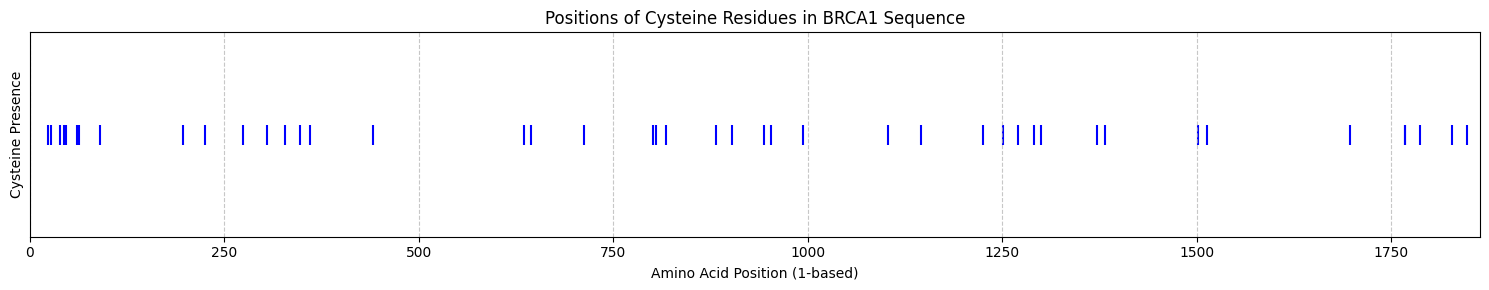

In [16]:

brca1_accession_id = "P38398"
protein_name = "BRCA1"


print(f"Fetching data for {protein_name} (Accession ID: {brca1_accession_id})...")
protein_data = fetch_protein_data(brca1_accession_id)

if protein_data:

    print(f"Extracting sequence for {protein_name}...")
    brca1_sequence = extract_protein_sequence(protein_data)

    if brca1_sequence:
        print(f"Sequence length: {len(brca1_sequence)} amino acids")
        print(f"First 20 amino acids: {brca1_sequence[:20]}")
        print(f"Last 20 amino acids: {brca1_sequence[-20:]}")


        print(f"Finding Cysteine positions in {protein_name} sequence...")
        cysteine_positions = find_cysteine_positions(brca1_sequence)
        print(f"Number of Cysteine residues found: {len(cysteine_positions)}")
        print(f"Cysteine positions (first 10): {cysteine_positions[:10]}...")


        print(f"Plotting Cysteine positions for {protein_name}...")
        plot_cysteine_positions(len(brca1_sequence), cysteine_positions, protein_name)
    else:
        print(f"Could not extract sequence for {protein_name}.")
else:
    print(f"Could not fetch protein data for {brca1_accession_id}.")